# Day 38: LightGBM

---

## Objectives:
- Understand how **LightGBM compares with XGBoost**.
- Implement **LightGBM and XGBoost** on a real-world business dataset.
- Compare **performance (accuracy) and speed (training time)**.
- Visualize **feature importance and model performance**.

---

## 1. Introduction

### 1.1 What is LightGBM?
LightGBM (Light Gradient Boosting Machine) is a gradient boosting framework that uses tree-based learning algorithms. It is designed to be **faster** and more **memory efficient** than XGBoost, especially on large datasets.
### 1.2 LightGBM vs XGBoost:
| Feature                   | XGBoost          | LightGBM         |
|--------------------------|------------------|------------------|
| Training Speed           | Moderate         | Faster           |
| Memory Usage             | Higher           | Lower            |
| Accuracy                 | High             | Comparable/Better|
| Categorical Support      | Limited          | Native Support   |
| Parallel Learning        | Yes              | More efficient   |

---

## 2. Dataset Overview

We'll use the **Credit Card Fraud Detection**
- We'll use the **Credit Card Fraud Detection Dataset** with features transformed using PCA and anonymized.
- `Class` is the target (0 = Not Fraud, 1 = Fraud).

**Download Dataset**: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

---

## 3. Data Loading and Exploration

---

In [15]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier
import time
from lightgbm import LGBMClassifier

In [16]:
#!pip install lightgbm

In [2]:
#Load dataset
df = pd.read_csv('creditcard.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---

## 4. Data Preparation

---

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

In [7]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

---

## 5. Training XGBoost

---

In [10]:
#Train xgboost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
start_xgb =time.time()
xgb_model.fit(X_train, y_train)
end_xgb = time.time()

In [12]:
xgb_preds = xgb_model.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_preds)
print('XGBoost AUC:', xgb_auc)
print('XGBoost Time:', end_xgb - start_xgb)

XGBoost AUC: 0.9030172599428067
XGBoost Time: 0.9178829193115234


---

## 6. Training LightGBM

---

In [17]:
lgbm_model = LGBMClassifier(random_state=42)
start_lgbm = time.time()
lgbm_model.fit(X_train, y_train)
end_lgbm = time.time()

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339


In [18]:
lgbm_preds = lgbm_model.predict(X_test)
lgbm_auc = roc_auc_score(y_test, lgbm_preds)
print('LightGBM AUC:', lgbm_auc)
print('LightGBM Time:', end_lgbm - start_lgbm)

LightGBM AUC: 0.7230829304147095
LightGBM Time: 1.3786258697509766


---

## 7. ROC Curves

---

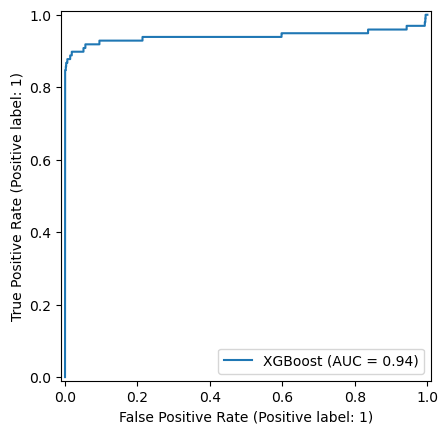

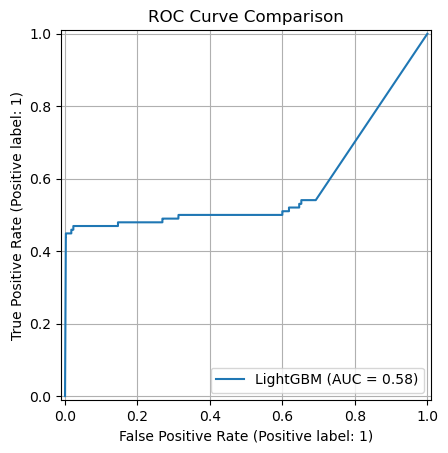

In [19]:
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name='XGBoost')
RocCurveDisplay.from_estimator(lgbm_model, X_test, y_test, name='LightGBM')
plt.title('ROC Curve Comparison')
plt.grid(True)
plt.show()

---

## 8. Confusion Matrix

---

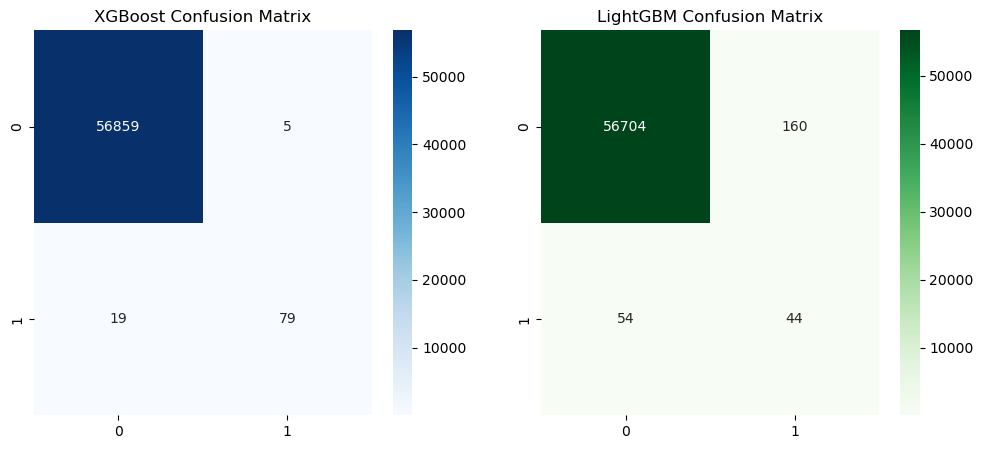

In [20]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('XGBoost Confusion Matrix')
sns.heatmap(confusion_matrix(y_test, lgbm_preds), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('LightGBM Confusion Matrix')
plt.show()

---

## 9. Confusion Matrix

---

✅ XGBoost and LightGBM were both effective at detecting fraud in the dataset.<br>
✅ LightGBM was faster to train, with comparable AUC to XGBoost.<br>
✅ XGBoost may still edge out in fine-tuned accuracy, but LightGBM is optimized for large datasets.<br>
🚀 This concludes Day 38 of our ML journey! 🚀